In [1]:
import tensorflow as tf
print(tf.keras.__version__)


3.13.2


In [2]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation='sigmoid')

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow


In [4]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Test"

In [5]:
# Define image size
img_height, img_width = 28, 28

In [6]:
# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
   class_path = os.path.join(folder, class_name)
   label = class_map[class_name]
   for filename in os.listdir(class_path):
    img_path = os.path.join(class_path, filename)
    # Load image using PIL
    img = Image.open(img_path).convert("L") # Convert to grayscale
    img = img.resize((img_width, img_height)) # Resize to (28,28)
    img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
    images.append(img)
    labels.append(label)
  return np.array(images), np.array(labels)

In [7]:
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

In [8]:
from sklearn.utils import shuffle

x_train, y_train = shuffle(x_train, y_train, random_state=42)

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


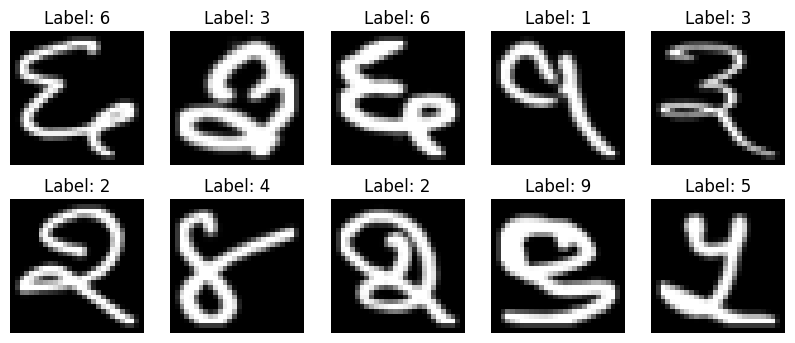

In [9]:
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

In [10]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
  [
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
  ]
)

In [11]:
model.compile(
optimizer="adam",
loss="categorical_crossentropy", # Changed to categorical_crossentropy for one-hot encoded labels
metrics=["accuracy"] # Track accuracy during training
)

In [12]:
batch_size = 128
epochs = 20
# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
# Train the model with callbacks and validation split
history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.2,
  callbacks=callbacks,
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4169 - loss: 1.8834 - val_accuracy: 0.7282 - val_loss: 1.1442
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8095 - loss: 0.7100 - val_accuracy: 0.8497 - val_loss: 0.4791
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8821 - loss: 0.3858 - val_accuracy: 0.9065 - val_loss: 0.3232
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9269 - loss: 0.2622 - val_accuracy: 0.9285 - val_loss: 0.2395
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9488 - loss: 0.1936 - val_accuracy: 0.9379 - val_loss: 0.1950
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9596 - loss: 0.1507 - val_accuracy: 0.9500 - val_loss: 0.1563
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9670 - loss: 0.1234 - val_accuracy: 0.9606 - val_loss: 0.1369
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9732 - loss: 0.1014 - val_accuracy:

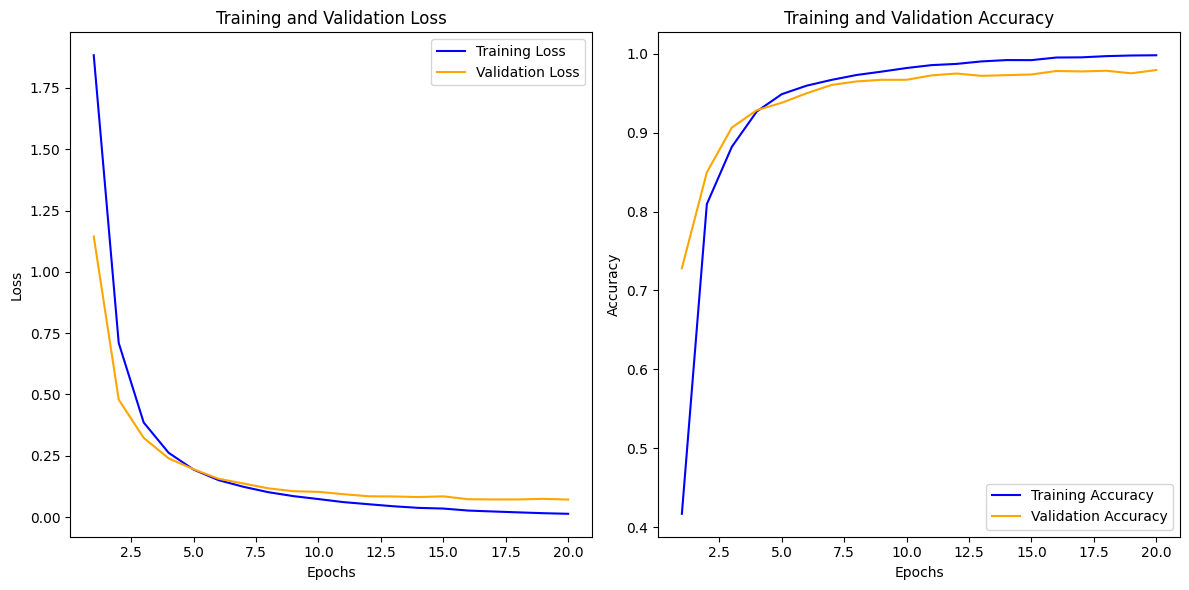

In [13]:
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 1s - 6ms/step - accuracy: 0.9797 - loss: 0.0790
Test accuracy: 0.9797


In [15]:
model.save('workshop4.h5')

In [16]:
loaded_model = tf.keras.models.load_model('workshop4.h5')

In [17]:
model.predict(
  x_test,
  batch_size=128,
  verbose=1,
  steps=100,
  callbacks=None
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


array([[9.97897744e-01, 6.31072151e-04, 7.75722128e-06, ...,
        8.00424823e-06, 9.68617562e-04, 4.54866415e-04],
       [9.99278784e-01, 3.38919126e-05, 2.61523780e-07, ...,
        1.79834329e-04, 1.11411384e-04, 2.41518574e-04],
       [9.99637246e-01, 2.11881161e-05, 2.73053729e-07, ...,
        6.11333453e-05, 1.03458449e-04, 1.62338692e-04],
       ...,
       [1.04966853e-06, 3.48683010e-04, 2.28678964e-05, ...,
        1.32473616e-07, 5.58698594e-06, 9.99162257e-01],
       [1.36395218e-04, 3.50277725e-04, 8.46908335e-07, ...,
        1.38264950e-05, 4.67579048e-06, 9.99015272e-01],
       [7.77902528e-07, 8.00010675e-05, 5.56953353e-07, ...,
        3.82643492e-07, 7.09575602e-07, 9.99308884e-01]], dtype=float32)

In [18]:
# Predict on test data
predictions = loaded_model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[6]}")
print(f"True label for first image: {np.argmax(y_test[6])}")

print(f"Predicted label for first image: {predicted_labels[1]}")
print(f"True label for first image: {np.argmax(y_test[1])}")

print(f"Predicted label for first image: {predicted_labels[1000]}")
print(f"True label for first image: {np.argmax(y_test[1000])}")


print(f"Predicted label for first image: {predicted_labels[1200]}")
print(f"True label for first image: {np.argmax(y_test[1200])}")

print(f"Predicted label for first image: {predicted_labels[1200]}")
print(f"True label for first image: {np.argmax(y_test[1201])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted label for first image: 0
True label for first image: 0
Predicted label for first image: 0
True label for first image: 0
Predicted label for first image: 3
True label for first image: 3
Predicted label for first image: 4
True label for first image: 4
Predicted label for first image: 4
True label for first image: 4
